# Pandas基础学习

Pandas是Python中用于数据分析和处理的核心库，提供了高性能、易用的数据结构和数据分析工具。

## 目录
1. [Pandas基础数据结构](#1-pandas基础数据结构)
   - [Series](#series)
   - [DataFrame](#dataframe)
2. [DataFrame的创建与属性](#2-dataframe的创建与属性)
3. [索引与切片](#3-索引与切片)
4. [数据修改与添加](#4-数据修改与添加)
5. [缺失数据处理](#5-缺失数据处理)
6. [数据合并与连接](#6-数据合并与连接)
7. [数据排序](#7-数据排序)

## 1. Pandas基础数据结构

Pandas主要提供了两种核心数据结构：**Series**和**DataFrame**。

### Series

**Series**是一维带标签的数组，可存储任意数据类型。
- 标签（索引）可以是整数、字符串等
- 支持numpy的大多数操作
- 自动对齐功能

In [1]:
import pandas as pd
import numpy as np

# 创建Series
# 参数：数据列表，索引（可选），数据类型（可选）
s = pd.Series([1, 3, 6, np.nan, 44, 1])
print(s)

# Series的基本属性
print('索引:', s.index)
print('值:', s.values)
print('数据类型:', s.dtype)

0     1.0
1     3.0
2     6.0
3     NaN
4    44.0
5     1.0
dtype: float64
索引: RangeIndex(start=0, stop=6, step=1)
值: [ 1.  3.  6. nan 44.  1.]
数据类型: float64


### DataFrame

**DataFrame**是二维带标签的数据结构，类似于电子表格或SQL表。
- 由行索引（index）和列索引（columns）组成
- 每列可以是不同的数据类型
- 支持行和列的操作

In [ ]:
# 创建日期索引
dates = pd.date_range('20260101', periods=6)
print('日期索引:', dates)

# 使用随机数创建DataFrame
# 参数：数据，行索引，列索引
df = pd.DataFrame(np.random.randn(6, 4), index=dates, columns=['a', 'b', 'c', 'd'])
print('随机数DataFrame:')
print(df)

# 使用整数创建DataFrame
df1 = pd.DataFrame(np.arange(12).reshape((3, 4)))
print('整数DataFrame:')
print(df1)

# 使用字典创建DataFrame
df2 = pd.DataFrame({'A': 1.,
                    'B': pd.Timestamp('20250102'),
                    'C': pd.Series(1, index=list(range(4)), dtype='float32'),
                    'D': np.array([3] * 4, dtype='int32'),
                    'E': pd.Categorical(['test', 'train', 'test', 'train']),
                    'F': 'foo'})
print('字典创建的DataFrame:')
print(df2)

## 2. DataFrame的创建与属性

DataFrame具有多种属性和方法，用于获取和操作数据结构的信息。

In [ ]:
# 查看DataFrame的数据类型
print('数据类型:')
print(df2.dtypes)

# 查看行索引
print('行索引:')
print(df2.index)

# 查看列索引
print('列索引:')
print(df2.columns)

# 查看所有值（numpy数组形式）
print('所有值:')
print(df2.values)

# 查看数据的统计摘要
print('统计摘要:')
print(df2.describe())

# 转置DataFrame
print('DataFrame转置:')
print(df2.T)

## 3. 索引与切片

Pandas提供了多种索引方式，包括标签索引、位置索引和混合索引。

### 常用索引方法：
- **df[column]**: 获取列（返回Series）
- **df.loc[label]**: 基于标签的索引
- **df.iloc[position]**: 基于位置的索引
- **df.ix[label/position]**: 混合索引（Pandas 0.20+已弃用）

In [ ]:
# 创建示例DataFrame
dates = pd.date_range('20240101', periods=6)
df = pd.DataFrame(np.arange(24).reshape((6, 4)), index=dates, columns=['A', 'B', 'C', 'D'])
print('原始DataFrame:')
print(df)

# 获取列（两种方式）
print('获取A列（方式1）:')
print(df['A'])
print('获取A列（方式2）:')
print(df.A)

# 切片获取行
print('获取前3行:')
print(df[0:3])
print('按日期获取行:')
print(df['20240102':'20240104'])

# 使用loc进行标签索引
print('使用loc获取特定行:')
print(df.loc['20240102'])
print('使用loc获取特定行和列:')
print(df.loc[:, ['A', 'B']])
print('使用loc获取特定单元格:')
print(df.loc['20240101', ['A', 'B']])

# 使用iloc进行位置索引
print('使用iloc获取第4行（索引从0开始）:')
print(df.iloc[3])
print('使用iloc获取特定范围的行和列:')
print(df.iloc[3:5, 1:3])
print('使用iloc获取不连续的行和列:')
print(df.iloc[[1, 3, 5], 1:3])

# 条件索引
print('条件索引（A列>8的行）:')
print(df[df.A > 8])

## 4. 数据修改与添加

Pandas提供了多种方式修改和添加数据。

In [ ]:
# 创建示例DataFrame
dates = pd.date_range('20240101', periods=6)
df = pd.DataFrame(np.arange(24).reshape((6, 4)), index=dates, columns=['A', 'B', 'C', 'D'])
print('原始DataFrame:')
print(df)

# 使用iloc修改特定值
df.iloc[2, 2] = 111
print('使用iloc修改后:')
print(df)

# 使用loc修改特定值
df.loc['20240101', 'B'] = 222
print('使用loc修改后:')
print(df)

# 使用条件修改
df[df.A > 8] = 0
print('使用条件修改后:')
print(df)

# 添加新列
df['F'] = np.nan
print('添加新列F:')
print(df)

# 添加带索引的新列
df['E'] = pd.Series([1, 2, 3, 4, 5, 6], index=pd.date_range('20240101', periods=6))
print('添加带索引的新列E:')
print(df)

## 5. 缺失数据处理

Pandas提供了灵活的缺失数据处理方法，包括检测、删除和填充。

### 常用方法：
- **df.isnull()**: 检测缺失值
- **df.notnull()**: 检测非缺失值
- **df.dropna()**: 删除缺失值
- **df.fillna()**: 填充缺失值

In [ ]:
# 创建包含缺失值的DataFrame
dates = pd.date_range('20240101', periods=6)
df = pd.DataFrame(np.arange(24).reshape((6, 4)), index=dates, columns=['A', 'B', 'C', 'D'])
df.iloc[0, 1] = np.nan
df.iloc[1, 2] = np.nan
print('包含缺失值的DataFrame:')
print(df)

# 删除包含缺失值的行（how='any'）
print('删除包含缺失值的行:')
print(df.dropna(axis=0, how='any'))

# 删除包含缺失值的列
print('删除包含缺失值的列:')
print(df.dropna(axis=1, how='any'))

# 删除所有值都是缺失值的行/列
print('删除所有值都是缺失值的列:')
print(df.dropna(axis=1, how='all'))

# 填充缺失值
print('填充缺失值为0:')
print(df.fillna(value=0))

# 检测缺失值
print('检测缺失值:')
print(df.isnull())

# 检查是否存在缺失值
print('是否存在缺失值:')
print(np.any(df.isnull()) == True)

## 6. 数据合并与连接


### 1.1 基础垂直合并

将结构相同的多个 DataFrame 上下拼接到一起。

* **核心参数**：`axis=0`（默认值，表示沿行方向垂直合并）。
* **重置索引**：由于直接合并会保留原始数据的索引，通常使用 `ignore_index=True` 来生成全新的连续索引（0, 1, 2...）。

```python
# 垂直合并三个 DataFrame
res = pd.concat([df1, df2, df3], axis=0)

# 垂直合并并生成新的连续索引（推荐做法）
res2 = pd.concat([df1, df2, df3], axis=0, ignore_index=True)

```

### 1.2 处理包含不同列的 DataFrame

当参与合并的 DataFrame 列名不完全一致时，可以使用 `join` 参数决定保留哪些列。

* **外连接 (`join='outer'`)**：默认模式。保留所有 DataFrame 中出现过的所有列，缺失的数据会自动填充为 `NaN`。
* **内连接 (`join='inner'`)**：只保留所有 DataFrame 共有的列，其他不重合的列会被丢弃。

```python
# 外连接：保留 df1 和 df2 的所有列 (a,b,c,d,e)
res_outer = pd.concat([df1, df2], join='outer')

# 内连接：只保留 df1 和 df2 共有的列 (b,c,d)
res_inner = pd.concat([df1, df2], join='inner')

```

---

### 2. 数据库风格连接：`pd.merge`

`pd.merge` 类似于关系型数据库（如 MySQL）中的 JOIN 操作，它通过匹配两个 DataFrame 中相同的“键 (Key)”来组合数据。

#### 2.1 基于键值合并 (`on`)

* **单键合并**：基于一列共有的列名进行匹配。
* **多键合并**：当匹配条件需要多个列共同决定时，可以传入列表，如 `on=['key1', 'key2']`。

```python
# 基于单一列 'key' 合并
res = pd.merge(left, right, on='key')

# 基于多列合并
res_multi = pd.merge(left, right, on=['key1', 'key2'])

```

#### 2.2 控制连接方式 (`how`)

决定以哪个 DataFrame 的键为准进行匹配，可选值包括：

* `'inner'`（默认）：只保留两边键值都能匹配上的行（交集）。
* `'outer'`：保留左右两边的所有键值，匹配不上的填充 `NaN`（并集）。
* `'left'`：以左边 DataFrame 的键值为准。
* `'right'`：以右边 DataFrame 的键值为准。

```python
# 根据 right DataFrame 的键值进行合并
res_right = pd.merge(left, right, on=['key1', 'key2'], how='right')

```

#### 2.3 来源指示器 (`indicator`)

在合并时，如果你想知道每一行数据是来自左表、右表还是两表都有，可以开启指示器。

* 设置 `indicator=True` 会新增一列 `_merge`，显示数据的来源（`both`, `left_only`, `right_only`）。
* 也可以传入字符串为其自定义列名，例如 `indicator='indicator_column'`。

#### 2.4 基于索引合并 (`left_index` & `right_index`)

有时候我们不需要基于普通的列去合并，而是需要基于数据的行索引（Index）来进行合并。

* 开启 `left_index=True` 和 `right_index=True` 即可让系统识别行索引作为匹配标准。

```python
# 基于两者的行索引进行外连接
res_idx = pd.merge(left, right, left_index=True, right_index=True, how='outer')
```

#### 2.5 处理重名列 (`suffixes`)

如果两个 DataFrame 中包含同名但非连接键的列（例如都有 `age` 列），Pandas 默认会自动加上 `_x` 和 `_y` 后缀以示区分。

* 使用 `suffixes` 参数可以自定义这些后缀，让数据更具可读性。

```python
# 处理重名列，分别加上 '_boy' 和 '_girl' 后缀
res_suffix = pd.merge(boys, girls, on='k', suffixes=['_boy', '_girl'], how='inner')
```


In [2]:
# 创建示例DataFrame
df1 = pd.DataFrame(np.ones((3, 4)) * 0, columns=['a', 'b', 'c', 'd'])
df2 = pd.DataFrame(np.ones((3, 4)) * 1, columns=['a', 'b', 'c', 'd'])
df3 = pd.DataFrame(np.ones((3, 4)) * 2, columns=['a', 'b', 'c', 'd'])

print('df1:')
print(df1)
print('df2:')
print(df2)
print('df3:')
print(df3)

# 沿行方向合并（垂直合并）
print('垂直合并:')
res = pd.concat([df1, df2, df3], axis=0)
print(res)

# 垂直合并并重置索引
print('垂直合并并重置索引:')
res2 = pd.concat([df1, df2, df3], axis=0, ignore_index=True)
print(res2)

# 创建不同列的DataFrame
df1 = pd.DataFrame(np.ones((3, 4)) * 0, columns=['a', 'b', 'c', 'd'], index=[1, 2, 3])
df2 = pd.DataFrame(np.ones((3, 4)) * 1, columns=['b', 'c', 'd', 'e'], index=[2, 3, 4])

print('df1:')
print(df1)
print('df2:')
print(df2)

# 外连接（保留所有列）
print('外连接（outer）:')
res = pd.concat([df1, df2], join='outer')
print(res)

# 内连接（只保留公共列）
print('内连接（inner）:')
res2 = pd.concat([df1, df2], join='inner')
print(res2)

# 内连接并重置索引
print('内连接并重置索引:')
res3 = pd.concat([df1, df2], join='inner', ignore_index=True)
print(res3)

df1:
     a    b    c    d
0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0
df2:
     a    b    c    d
0  1.0  1.0  1.0  1.0
1  1.0  1.0  1.0  1.0
2  1.0  1.0  1.0  1.0
df3:
     a    b    c    d
0  2.0  2.0  2.0  2.0
1  2.0  2.0  2.0  2.0
2  2.0  2.0  2.0  2.0
垂直合并:
     a    b    c    d
0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0
0  1.0  1.0  1.0  1.0
1  1.0  1.0  1.0  1.0
2  1.0  1.0  1.0  1.0
0  2.0  2.0  2.0  2.0
1  2.0  2.0  2.0  2.0
2  2.0  2.0  2.0  2.0
垂直合并并重置索引:
     a    b    c    d
0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0
3  1.0  1.0  1.0  1.0
4  1.0  1.0  1.0  1.0
5  1.0  1.0  1.0  1.0
6  2.0  2.0  2.0  2.0
7  2.0  2.0  2.0  2.0
8  2.0  2.0  2.0  2.0
df1:
     a    b    c    d
1  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0
3  0.0  0.0  0.0  0.0
df2:
     b    c    d    e
2  1.0  1.0  1.0  1.0
3  1.0  1.0  1.0  1.0
4  1.0  1.0  1.0  1.0
外连接（outer）:
     a    b    c    d    e
1  0.0  0.0  0.0  0.0  NaN
2  0.0  0.0 

In [2]:
# SQL风格的合并
# 创建示例DataFrame
import pandas as pd
import numpy as np
left = pd.DataFrame({'key': ['K0', 'K1', 'K2', 'K3'],
                     'A': ['A0', 'A1', 'A2', 'A3'],
                     'B': ['B0', 'B1', 'B2', 'B3']})
right = pd.DataFrame({'key': ['K0', 'K1', 'K2', 'K3'],
                     'C': ['C0', 'C1', 'C2', 'C3'],
                     'D': ['D0', 'D1', 'D2', 'D3']})

print('left:')
print(left)
print('right:')
print(right)

# 基于key列合并
print('基于key列合并:')
res = pd.merge(left, right, on='key')
print(res)

# 多键合并
left = pd.DataFrame({'key1': ['K0', 'K0', 'K1', 'K2'],
                     'key2': ['K0', 'K1', 'K0', 'K1'],
                     'A': ['A0', 'A1', 'A2', 'A3'],
                     'B': ['B0', 'B1', 'B2', 'B3']})
right = pd.DataFrame({'key1': ['K0', 'K1', 'K1', 'K2'],
                      'key2': ['K0', 'K0', 'K0', 'K0'],
                     'C': ['C0', 'C1', 'C2', 'C3'],
                     'D': ['D0', 'D1', 'D2', 'D3']})

print('多键合并 - left:')
print(left)
print('多键合并 - right:')
print(right)
#how = ['left','right','outer','inner']
res=pd.merge(left,right,on=['key1','key2'])#默认 how=‘inner’
print('多键合并结果：',res)
res = pd.merge(left,right,on=['key1','key2'],how='right')#根据right的key来合并

#indicator
print('==========')
print('the use of indicator')
df1=pd.DataFrame({'col1':[0,1],'col_left':['a','b']})
df2=pd.DataFrame({'col1':[1,2,2],'col_right':[2,2,2]})
print(df1)
print(df2)
res=pd.merge(df1,df2,on='col1',how='outer',indicator=True)
print(res)
res=pd.merge(df1,df2,on='col1',how='outer',indicator='indicator_column')#改名字
print(res)
#give the indicator a custom name
res = pd.merge(df1,df2,on='col1',how='outer',indicator=False) #default 
print(res)
#merge by index
print('==========')
print('merge by index')
left=pd.DataFrame({'A':['A0','A1','A2'],
                   'B':['B0','B1','B2']},
                   index=['K0','K1','K2'])
right = pd.DataFrame({'C':['C0','C2','C3'],
                      'D':['D0','D2','D3']},
                      index=['K0','K2','K3'])
print(left)
print(right)
#left_index and right_index
res = pd.merge(left,right,left_index=True,right_index=True,how='outer')
print(res)
res = pd.merge(left,right,left_index=True,right_index=True,how='inner')
print(res)

#handle overlapping
print('==========')
print("handle overlapping")
boys = pd.DataFrame({'k':['K0','K1','K2'],'age':[1,2,3]})
girls = pd.DataFrame({'k':['K0','K0','K3'],'age':[4,5,6]})
print('boys:',boys)
print('girls:',girls)
res = pd.merge(boys,girls,on='k',how='inner')
print('无suffixes:',res)
res = pd.merge(boys,girls,on='k',suffixes=['_boy','_girl'],how='inner')
print(res)

left:
  key   A   B
0  K0  A0  B0
1  K1  A1  B1
2  K2  A2  B2
3  K3  A3  B3
right:
  key   C   D
0  K0  C0  D0
1  K1  C1  D1
2  K2  C2  D2
3  K3  C3  D3
基于key列合并:
  key   A   B   C   D
0  K0  A0  B0  C0  D0
1  K1  A1  B1  C1  D1
2  K2  A2  B2  C2  D2
3  K3  A3  B3  C3  D3
多键合并 - left:
  key1 key2   A   B
0   K0   K0  A0  B0
1   K0   K1  A1  B1
2   K1   K0  A2  B2
3   K2   K1  A3  B3
多键合并 - right:
  key1 key2   C   D
0   K0   K0  C0  D0
1   K1   K0  C1  D1
2   K1   K0  C2  D2
3   K2   K0  C3  D3
多键合并结果：   key1 key2   A   B   C   D
0   K0   K0  A0  B0  C0  D0
1   K1   K0  A2  B2  C1  D1
2   K1   K0  A2  B2  C2  D2
the use of indicator
   col1 col_left
0     0        a
1     1        b
   col1  col_right
0     1          2
1     2          2
2     2          2
   col1 col_left  col_right      _merge
0     0        a        NaN   left_only
1     1        b        2.0        both
2     2      NaN        2.0  right_only
3     2      NaN        2.0  right_only
   col1 col_left  col_right indi

## 7. 数据排序

Pandas提供了灵活的数据排序功能，可以按索引或值排序。

### 常用方法：
- **df.sort_index()**: 按索引排序
- **df.sort_values()**: 按值排序

In [14]:
# 创建示例DataFrame
dates = pd.date_range('20260101', periods=6)
df = pd.DataFrame(np.random.randn(6, 4), index=dates, columns=['a', 'b', 'c', 'd'])

print('原始DataFrame:')
print(df)

# 按列索引降序排序
print('按列索引降序排序:')
print(df.sort_index(axis=1, ascending=False))

# 按行索引降序排序
print('按行索引降序排序:')
print(df.sort_index(axis=0, ascending=False))

# 创建带分类列的DataFrame
df2 = pd.DataFrame({'A': 1.,
                    'B': pd.Timestamp('20250102'),
                    'C': pd.Series(1, index=list(range(4)), dtype='float32'),
                    'D': np.array([3] * 4, dtype='int32'),
                    'E': pd.Categorical(['test', 'train', 'test', 'train']),
                    'F': 'foo'})

# 按值排序（按E列）
print('按E列值排序:')
print(df2.sort_values(by='E'))

原始DataFrame:
                   a         b         c         d
2026-01-01  0.316803 -0.325084 -0.305657 -0.954938
2026-01-02 -0.102551 -1.217129 -0.139964  1.492705
2026-01-03 -0.426693  0.453129 -0.802201  0.603732
2026-01-04 -0.597203 -0.292428 -1.620609 -1.385544
2026-01-05  1.218986 -1.301304 -0.780146 -0.576470
2026-01-06 -1.918849  2.101206 -0.643806 -0.618457
按列索引降序排序:
                   d         c         b         a
2026-01-01 -0.954938 -0.305657 -0.325084  0.316803
2026-01-02  1.492705 -0.139964 -1.217129 -0.102551
2026-01-03  0.603732 -0.802201  0.453129 -0.426693
2026-01-04 -1.385544 -1.620609 -0.292428 -0.597203
2026-01-05 -0.576470 -0.780146 -1.301304  1.218986
2026-01-06 -0.618457 -0.643806  2.101206 -1.918849
按行索引降序排序:
                   a         b         c         d
2026-01-06 -1.918849  2.101206 -0.643806 -0.618457
2026-01-05  1.218986 -1.301304 -0.780146 -0.576470
2026-01-04 -0.597203 -0.292428 -1.620609 -1.385544
2026-01-03 -0.426693  0.453129 -0.802201  0.60373

## 8.plot画图


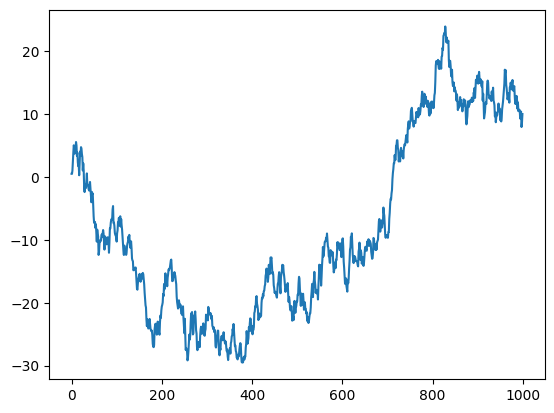

          A         B         C         D
0 -1.312338 -0.559461 -1.493835  1.922409
1 -2.567416 -0.336232  0.066493  2.225931
2 -1.081829 -1.949578 -0.880578  1.541156
3 -1.734806 -0.768881 -1.371436  2.431227
4 -1.767985 -1.688119 -1.114026  2.623469


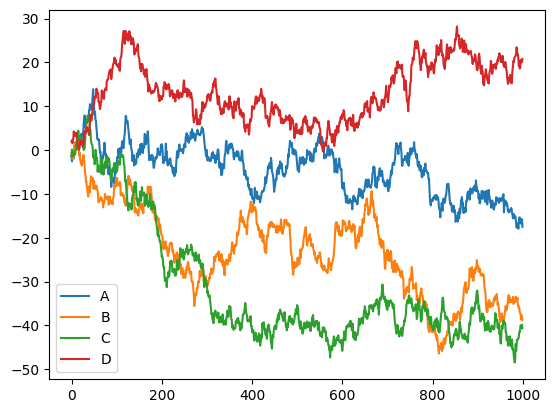

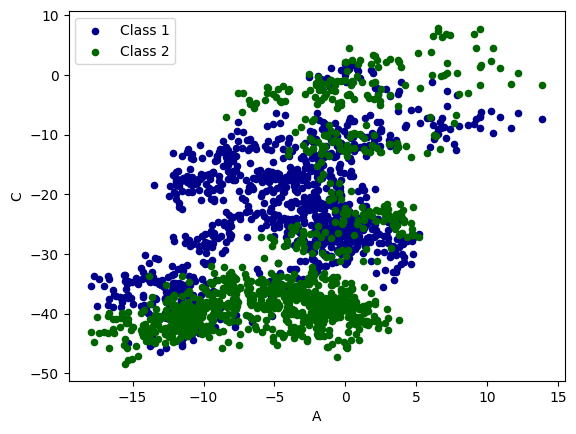

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#plot data 


#Series
data = pd.Series(np.random.randn(1000),index=np.arange(1000))
data = data.cumsum()#累加
data.plot()
plt.show()

#DataFrame
data = pd.DataFrame(np.random.randn(1000,4),index=np.arange(1000),columns=list('ABCD'))
data =data.cumsum()
print(data.head())#first five datas
data.plot()
plt.show()
#plot methods:
#'bar','hist,'box','kde','area','scatter','hexbin','pie'
ax=data.plot.scatter(x='A',y='B',color='DarkBlue',label='Class 1')
data.plot.scatter(x='A',y='C',color='DarkGreen',label='Class 2',ax=ax)
#关键点 ax=ax:第一行代码创建了一个绘图对象并赋值给变量 ax。
#第二行代码通过 ax=ax 参数，告诉程序：“请把这张图画在刚才那个坐标系里”。
#结果：你会看到两组不同颜色、不同标签的散点出现在同一张图上。

plt.show()